# Si：生成位移、计算力，再恢复 FC2 和 FC3

从硅原胞和理想超胞开始，用 ASE 的 Erhart–Albe Si-II Tersoff 势计算有限差分所需的力。最后得到二阶、三阶力常数，画声子谱，并用 phono3py 计算一次 300 K 热导率。

势文件与结构已随仓库提供，不需要外部电子结构程序。运行环境见[教程总览](index.md)。

## 1. 读取结构并准备 calculator

`POSCAR` 是 2 原子的金刚石原胞，`SPOSCAR` 是 $4\times4\times4$、128 原子的超胞。使用配套参考结构，可以保持后续位移、力和导出的原子顺序一致。

Tersoff 势是本例的力来源。换成自己的材料时，先替换这两份结构和适用的 calculator；MLFCS 的采样与重建接口不依赖 Tersoff。

In [1]:
from pathlib import Path
import logging
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
from ase.calculators.tersoff import Tersoff
from ase.calculators.singlepoint import SinglePointCalculator
from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FiniteDifference
from mlfcs.phonon import Harmonic
from mlfcs.tools import EstimateCutoff

logging.getLogger("mlfcs").setLevel(logging.WARNING)
DATA = Path("data/si")
if not DATA.exists():
    DATA = Path("docs/notebooks") / DATA
SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-si-fd-"))
primitive = read(DATA / "POSCAR")
supercell = read(DATA / "SPOSCAR")
calculator = Tersoff.from_lammps(DATA / "Erhart-Albe-Si-II.tersoff")
print(f"原胞：{len(primitive)} 原子；超胞：{len(supercell)} 原子")

原胞：2 原子；超胞：128 原子


## 2. 选择相互作用范围

这里 FC2 保留前 7 个近邻壳层，FC3 保留前 6 个。`EstimateCutoff.get(n)` 返回第 $n$ 与第 $n+1$ 壳之间的中点，给 `ClusterSpace` 的仍是正的 Å 半径。这些范围沿用教学模型，不能替代截断收敛检查。

二阶、三阶默认最大体阶分别为 2、3，允许各阶涉及相应数量的不同原子位置。`asr=True` 提前准备平移约束；差分重建先恢复物理参数，再将它们投影到约束空间。

In [2]:
shells = EstimateCutoff(primitive)
cutoffs = {2: shells.get(7), 3: shells.get(6)}
space = ClusterSpace(primitive, cutoffs=cutoffs, asr=True)
mapping = ClusterMap(space, supercell)
mapping.rank_info().require_full()
for order, cutoff in cutoffs.items():
    print(f"FC{order} 截断：{cutoff:.3f} Å")
print(f"物理参数：{space.n_parameters}；ASR 自由参数：{space.n_free_parameters}")

FC2 截断：7.419 Å
FC3 截断：6.901 Å
物理参数：499；ASR 自由参数：464


## 3. 为 FC2 生成位移结构

二阶力常数来自力的一阶位移导数。`order=2` 选择恢复的阶数，`disps` 的单位是 Å。

取 0.005、0.010、0.015 Å 三个步长，在 $h^2$ 上外推到零步长，减少有限差分截断误差。步长太小会放大力噪声；太大则会引入更多高阶项。换 calculator 时应重新检查步长收敛。

`sow()` 按固定顺序返回结构；后面的计算与数据收集必须保持这个顺序。

In [3]:
disps = (0.005, 0.010, 0.015)
fd2 = FiniteDifference(mapping, order=2, disps=disps)
print(f"FC2 需要计算 {fd2.n_configurations} 个结构")

FC2 需要计算 18 个结构


## 4. 计算力并重建 FC2

每个结构先交给 Tersoff 计算力，再用 `SinglePointCalculator` 保存计算结果。`ForceDataset` 随后读取这些存储力，不重新调用 calculator；`reap()` 完成外推、参数恢复及 ASR 投影。

换成 DFT 时，这个循环可以拆成提交任务和收集结果两步。按原采样序号排列返回帧，不要按作业完成时间排序：`reap()` 不会从几何自动修复顺序。

In [4]:
structures = []
for atoms in fd2.sow():
    atoms.calc = calculator
    forces = atoms.get_forces()
    atoms.calc = SinglePointCalculator(atoms, forces=forces)
    structures.append(atoms)
dataset2 = ForceDataset(mapping, structures)
fc2 = fd2.reap(dataset2)
print(f"已恢复 FC2：{len(fc2.coefficients[2])} 个物理参数")

已恢复 FC2：28 个物理参数


## 5. 用同样的方法恢复 FC3

三阶力常数需要力的二阶混合导数，因此位移组合比 FC2 多。重复坐标的符号位移会在同一个自由度上累加，即使两帧位置相同，也应保留采样序列中的两帧。

这里只把 `order` 换成 3，仍使用同一 mapping、calculator 和三步外推。

In [5]:
fd3 = FiniteDifference(mapping, order=3, disps=disps)
print(f"FC3 需要计算 {fd3.n_configurations} 个结构")
structures = []
for atoms in fd3.sow():
    atoms.calc = calculator
    forces = atoms.get_forces()
    atoms.calc = SinglePointCalculator(atoms, forces=forces)
    structures.append(atoms)
dataset3 = ForceDataset(mapping, structures)
fc3 = fd3.reap(dataset3)
print(f"已恢复 FC3：{len(fc3.coefficients[3])} 个物理参数")

FC3 需要计算 408 个结构


已恢复 FC3：471 个物理参数


## 6. 先看二阶模型的声子谱

`Harmonic` 直接使用 FC2，不需要先导出文件。ASE 根据原胞晶胞选默认高对称路径；200 个 q 点用于绘图。频率单位是 THz，负值表示虚频。

这张图可检查是否出现明显异常，但 ASR 或平滑曲线都不能证明模型已经收敛。

路径：GXWKGLUWLK,UX；每个 q 点 6 个模式


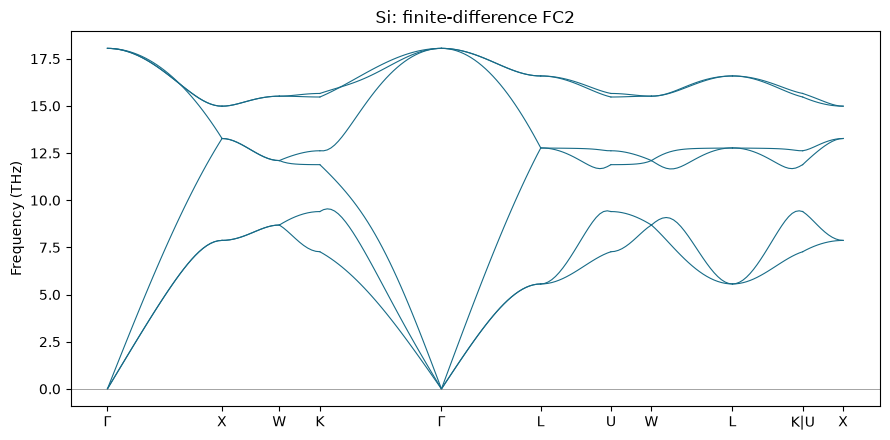

In [6]:
bands = Harmonic(fc2).run_band_path(npoints=200)
print(f"路径：{bands.path}；每个 q 点 {bands.frequencies_thz.shape[1]} 个模式")
fig, axis = plt.subplots(figsize=(9, 4.5))
for segment in bands.segments:
    axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color="#176b87", lw=0.8)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
axis.axhline(0, color="0.5", lw=0.5)
axis.set_ylabel("Frequency (THz)")
axis.set_title("Si: finite-difference FC2")
fig.tight_layout()
plt.show()

## 7. 把 FC2 和 FC3 交给 phono3py

热导率还需要三阶散射，这里分别导出二阶、三阶的 HDF5 文件。临时目录避免覆盖自己的研究结果；实际计算可以将 `SCRATCH` 换成工作目录。

为保持导出顺序，用参考超胞作为 phono3py 的输入晶胞、超胞矩阵取单位阵，再用 MLFCS 超胞矩阵的逆的转置恢复 Phonopy 列向量约定下的原胞基底。`p2s_map` 选出 phono3py 原胞代表原子的首指标；不要假设它总是前几个原子。

In [7]:
fc2_file = SCRATCH / "fc2.hdf5"
fc3_file = SCRATCH / "fc3.hdf5"
fc2.write(fc2_file, mapping, format="phonopy", storage="hdf5", order=2)
fc3.write(fc3_file, mapping, format="phono3py", storage="hdf5", order=3)
from phono3py import Phono3py
from phono3py.file_IO import read_fc2_from_hdf5, read_fc3_from_hdf5
from phonopy.structure.atoms import PhonopyAtoms

unitcell = PhonopyAtoms(
    symbols=supercell.get_chemical_symbols(), cell=supercell.cell.array,
    scaled_positions=supercell.get_scaled_positions(), masses=supercell.get_masses(),
)
ph3 = Phono3py(unitcell, np.eye(3, dtype=int),
               primitive_matrix=np.linalg.inv(mapping.supercell_matrix).T, log_level=0)
p2s = ph3.phonon_primitive.p2s_map
ph3.fc2 = read_fc2_from_hdf5(str(fc2_file))[p2s]
ph3.fc3 = read_fc3_from_hdf5(str(fc3_file))[p2s]

## 8. 计算一次 300 K 热导率

用 $10\times10\times10$ q 网格做弛豫时间近似（RTA），并加入天然同位素散射。`write_kappa=False` 避免在 notebook 目录生成结果文件，数值直接保存在下方输出中。

这只是势模型和当前网格的教学结果，不是硅实验热导率的复现。定量研究还需检查 q 网格、相互作用截断与力计算精度。

In [8]:
TEMPERATURES = (300,)
ph3.mesh_numbers = (10, 10, 10)
ph3.init_phph_interaction()
ph3.run_thermal_conductivity(temperatures=TEMPERATURES, is_isotope=True,
                            write_kappa=False, log_level=0)
kappa = ph3.thermal_conductivity.kappa.reshape(-1, 6)
print("T (K)    κxx       κyy       κzz   [W/(m·K)]")
for temperature, values in zip(TEMPERATURES, kappa):
    print(f"{temperature:5g}  {values[0]:8.3f}  {values[1]:8.3f}  {values[2]:8.3f}")

T (K)    κxx       κyy       κzz   [W/(m·K)]
  300   237.230   237.230   237.230


## 接下来

我们从位移生成开始，实际计算了每帧的力，分别恢复 FC2 与 FC3，再检查声子谱和 RTA 热导率。差分输出只含所选阶数，多个步长的结果由 `reap()` 自动外推。

换材料最先修改参考结构与超胞、calculator、截断和步长；使用外部力时保持采样序号和原子顺序。详细接口见[有限差分](../finite-difference-api.md)，外推公式见[力常数恢复](../theory/reconstruction.md)。

下一份 [Ba8Ga16Ge30 教程](ba8ga16ge30.ipynb)不再生成差分位移，而是从分子动力学快照联合拟合 FC2、FC3。